# Air Cargo Profitability Analysis

## Exploratory Data Analysis (EDA)

This notebook explores international air cargo data collected from the Incheon International Airport OpenAPI.

Objectives:
- Understand cargo volume by destination
- Analyze cargo flow patterns
- Identify regional cargo characteristics
- Generate business insights before profitability modeling

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent

input_path = (
    BASE_DIR
    / "data"
    / "processed"
    / "cargo_with_route.csv"
)

df = pd.read_csv(input_path)

df.head()

,region_x,country,arrival_cargo_tons,departure_cargo_tons,total_cargo_tons,net_cargo_flow,cargo_direction,departure_ratio,arrival_ratio,region_y
0,Oceania,Hawaii,19,0,19,-19,Inbound,0.000000,1.000000,North America
1,Oceania,Australia,433,0,433,-433,Inbound,0.000000,1.000000,Oceania
2,Southeast Asia,Malaysia,1717,1736,3453,19,Outbound,0.502751,0.497249,Southeast Asia
3,Southeast Asia,Vietnam,28851,55375,84226,26524,Outbound,0.657457,0.342543,Southeast Asia
4,Southeast Asia,Singapore,9365,6403,15768,-2962,Inbound,0.406076,0.593924,Southeast Asia


# Analysis 1

## Business Question

**Which destinations handle the largest cargo volume?**

In [46]:
top10_total = (
    df.sort_values(
        by="total_cargo_tons",
        ascending=False
    )
    .head(10)
)

top10_total

,region_x,country,arrival_cargo_tons,departure_cargo_tons,total_cargo_tons,net_cargo_flow,cargo_direction,departure_ratio,arrival_ratio,region_y
12,Americas,United States,107313,110606,217919,3293,Outbound,0.507556,0.492444,North America
35,Northeast Asia,China,91039,93207,184246,2168,Outbound,0.505883,0.494117,Northeast Asia
34,Northeast Asia,Japan,42785,46301,89086,3516,Outbound,0.519734,0.480266,Northeast Asia
3,Southeast Asia,Vietnam,28851,55375,84226,26524,Outbound,0.657457,0.342543,Southeast Asia
19,Europe,Germany,60155,22945,83100,-37210,Inbound,0.276113,0.723887,Europe
10,Northeast Asia,Hong Kong,24111,48929,73039,24818,Outbound,0.669902,0.330111,East Asia
37,Middle East,Qatar,11244,18276,29519,7032,Outbound,0.619127,0.380907,Middle East
29,Europe,Italy,17207,7203,24409,-10004,Inbound,0.295096,0.704945,Europe
18,Europe,Norway,21230,160,21390,-21070,Inbound,0.007480,0.992520,Europe
17,Europe,Netherlands,15717,4192,19909,-11525,Inbound,0.210558,0.789442,Europe


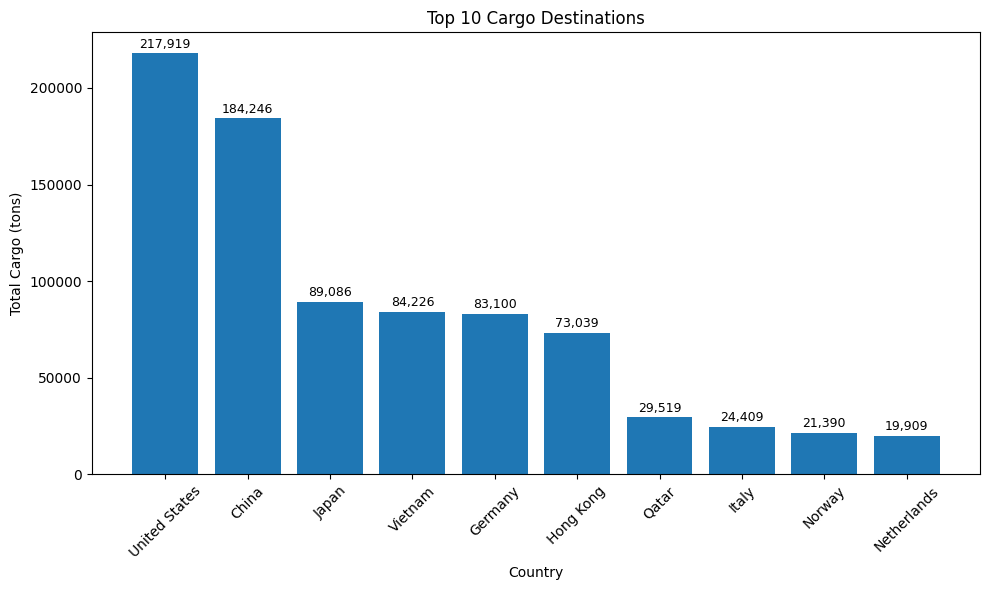

In [47]:
plt.figure(figsize=(10,6))

plt.bar(
    top10_total["country"],
    top10_total["total_cargo_tons"]
)

plt.title("Top 10 Cargo Destinations")
plt.xlabel("Country")
plt.ylabel("Total Cargo (tons)")
plt.xticks(rotation=45)

for i, value in enumerate(top10_total["total_cargo_tons"]):
    plt.text(i, value + 3000, f"{value:,}", ha="center", fontsize=9)

plt.tight_layout()

plt.show()

### Insight

- The United States handled the largest cargo volume among all destinations, followed by China.
- Cargo volume drops noticeably after the top two destinations, indicating that the cargo network is concentrated on a few major markets.
- Japan, Vietnam, and Germany also represent important cargo destinations, reflecting strong regional trade and manufacturing activities.

### Business Recommendation

- Airlines should prioritize capacity planning for high-demand routes such as the United States and China.
- Diversifying cargo operations across emerging markets could reduce dependence on a small number of major destinations.

# Analysis 2

## Business Question

Which destinations receive the largest outbound cargo volume from Incheon International Airport?

In [48]:
top10_outbound = (
    df.sort_values(
        by="departure_cargo_tons",
        ascending=False
    )
    .head(10)
)

top10_outbound[["country", "departure_cargo_tons"]]

,country,departure_cargo_tons
12,United States,110606
35,China,93207
3,Vietnam,55375
10,Hong Kong,48929
34,Japan,46301
19,Germany,22945
37,Qatar,18276
27,Austria,16140
25,Azerbaijan,12245
20,Luxembourg,10306


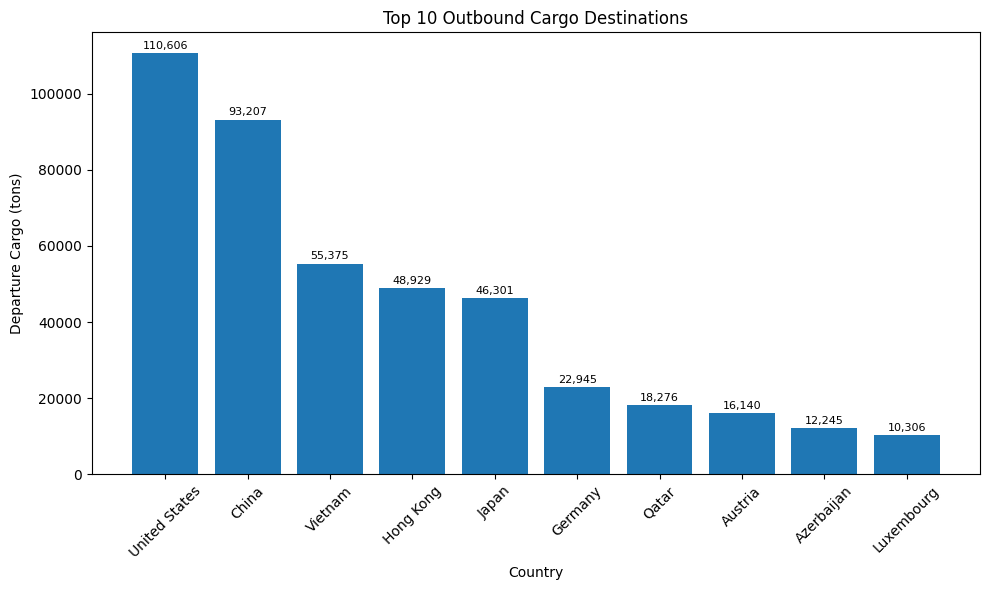

In [49]:
plt.figure(figsize=(10,6))

plt.bar(
    top10_outbound["country"],
    top10_outbound["departure_cargo_tons"]
)

plt.title("Top 10 Outbound Cargo Destinations")
plt.xlabel("Country")
plt.ylabel("Departure Cargo (tons)")

plt.xticks(rotation=45)

# show the value of each bar on top of the bar
for i, value in enumerate(top10_outbound["departure_cargo_tons"]):
    plt.text(
        i,
        value + max(top10_outbound["departure_cargo_tons"]) * 0.01,
        f"{value:,}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Insight

- The United States and China remain the two largest outbound cargo destinations.
- Vietnam ranks higher than Japan in outbound cargo volume, suggesting strong export activity driven by manufacturing and supply chain operations.
- Hong Kong also records substantial outbound cargo, reflecting its role as a regional logistics hub.
- Several destinations such as Austria, Azerbaijan, and Luxembourg appear in the outbound ranking despite not being among the highest in total cargo volume, indicating route-specific export demand.


### Business Recommendation

- Airlines should maintain sufficient cargo capacity on major export routes to the United States and China.
- The rapid growth of outbound cargo to Vietnam suggests opportunities for expanding cargo services supporting manufacturing supply chains.
- Cargo carriers should monitor emerging export destinations to identify potential market expansion opportunities.

# Analysis 3

## Business Question

Which destinations send the largest inbound cargo volume to Incheon International Airport?

In [50]:
top10_inbound = (
    df.sort_values(
        by="arrival_cargo_tons",
        ascending=False
    )
    .head(10)
)

top10_inbound[["country", "arrival_cargo_tons"]]

,country,arrival_cargo_tons
12,United States,107313
35,China,91039
19,Germany,60155
34,Japan,42785
3,Vietnam,28851
10,Hong Kong,24111
18,Norway,21230
29,Italy,17207
17,Netherlands,15717
21,Belgium,11413


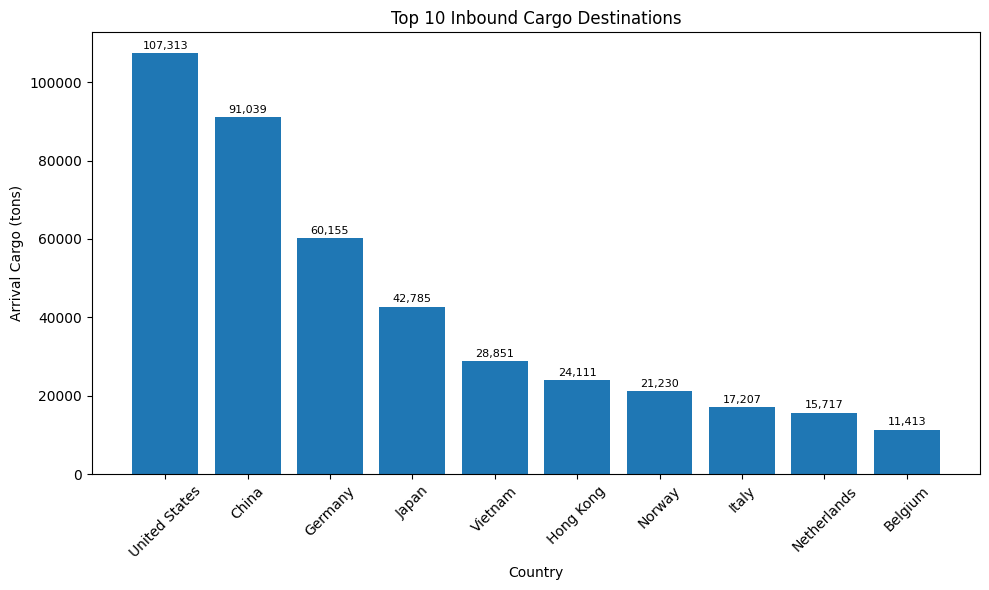

In [51]:
plt.figure(figsize=(10, 6))

plt.bar(
    top10_inbound["country"],
    top10_inbound["arrival_cargo_tons"]
)

plt.title("Top 10 Inbound Cargo Destinations")
plt.xlabel("Country")
plt.ylabel("Arrival Cargo (tons)")

plt.xticks(rotation=45)

# 값 표시
for i, value in enumerate(top10_inbound["arrival_cargo_tons"]):
    plt.text(
        i,
        value + max(top10_inbound["arrival_cargo_tons"]) * 0.01,
        f"{value:,}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Insight

- The United States and China dominate both inbound and outbound cargo flows, highlighting their importance as strategic cargo markets.
- Germany ranks significantly higher in inbound cargo than outbound cargo, suggesting that it is a major source of imports to South Korea.
- Vietnam records stronger outbound cargo than inbound cargo, reflecting South Korea's export-oriented manufacturing supply chain.
- Hong Kong remains an important logistics hub with substantial cargo movement in both directions.

### Business Recommendation

- Airlines should continue investing in cargo capacity on routes to the United States and China due to strong two-way demand.
- The high inbound cargo volume from Germany highlights the importance of maintaining reliable European cargo connections.
- The imbalance between outbound and inbound cargo for Vietnam suggests opportunities to improve aircraft load factors by increasing return cargo.


# Analysis 4

## Business Question

Which destinations are net exporters and which are net importers?

In [52]:
top_export = (
    df.sort_values(
        by="net_cargo_flow",
        ascending=False
    )
    .head(10)
)

top_export[["country", "net_cargo_flow"]]

,country,net_cargo_flow
3,Vietnam,26524
10,Hong Kong,24818
27,Austria,16140
37,Qatar,7032
25,Azerbaijan,4887
20,Luxembourg,4233
34,Japan,3516
12,United States,3293
8,Taiwan,2942
35,China,2168


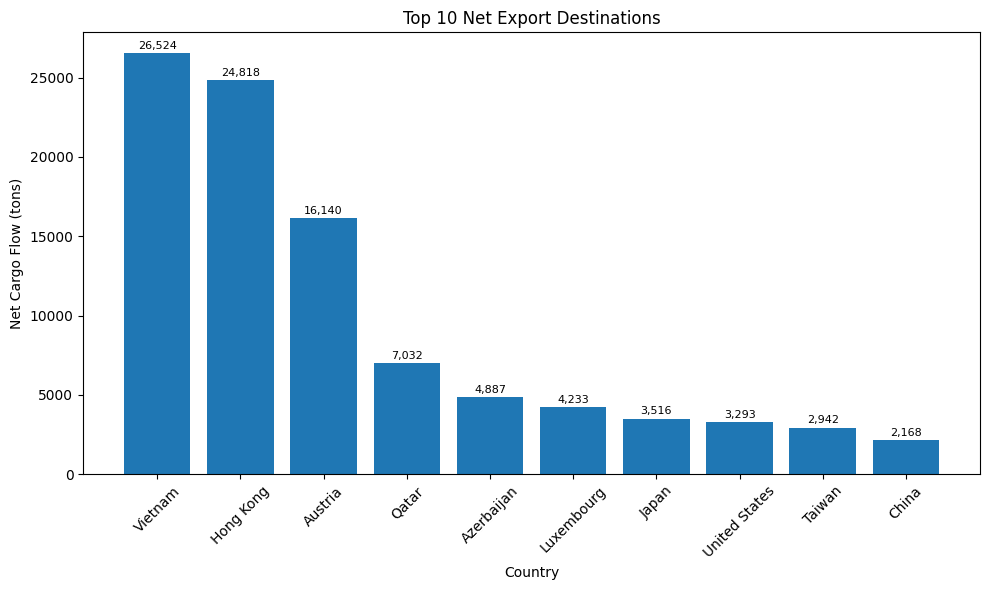

In [53]:
plt.figure(figsize=(10,6))

plt.bar(
    top_export["country"],
    top_export["net_cargo_flow"]
)

plt.title("Top 10 Net Export Destinations")
plt.xlabel("Country")
plt.ylabel("Net Cargo Flow (tons)")

plt.xticks(rotation=45)

for i, value in enumerate(top_export["net_cargo_flow"]):
    plt.text(
        i,
        value + max(top_export["net_cargo_flow"])*0.01,
        f"{value:,}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Insight

- Vietnam and Hong Kong are the strongest export-oriented cargo destinations.
- The United States and China show relatively balanced two-way cargo flows despite handling the largest cargo volumes.
- Net cargo flow provides a clearer picture of trade direction than total cargo volume alone.
- Distinguishing export-oriented and import-oriented destinations can support route planning and cargo capacity management.

### Business Recommendation

- Increase outbound cargo capacity on export-oriented routes such as Vietnam and Hong Kong.
- Maintain balanced capacity planning for routes to the United States and China, where two-way cargo demand is consistently high.
- Analyze import-oriented routes to identify opportunities for improving return cargo utilization.


# Analysis 5

## Business Question

Which regions handle the largest cargo volume?

In [54]:
cargo_by_region = (
    df.groupby("region_x", as_index=False)["total_cargo_tons"]
      .sum()
      .sort_values(
          by="total_cargo_tons",
          ascending=False
      )
)

cargo_by_region

,region_x,total_cargo_tons
3,Northeast Asia,349494
1,Europe,248888
0,Americas,228609
5,Southeast Asia,109373
2,Middle East,30411
4,Oceania,452


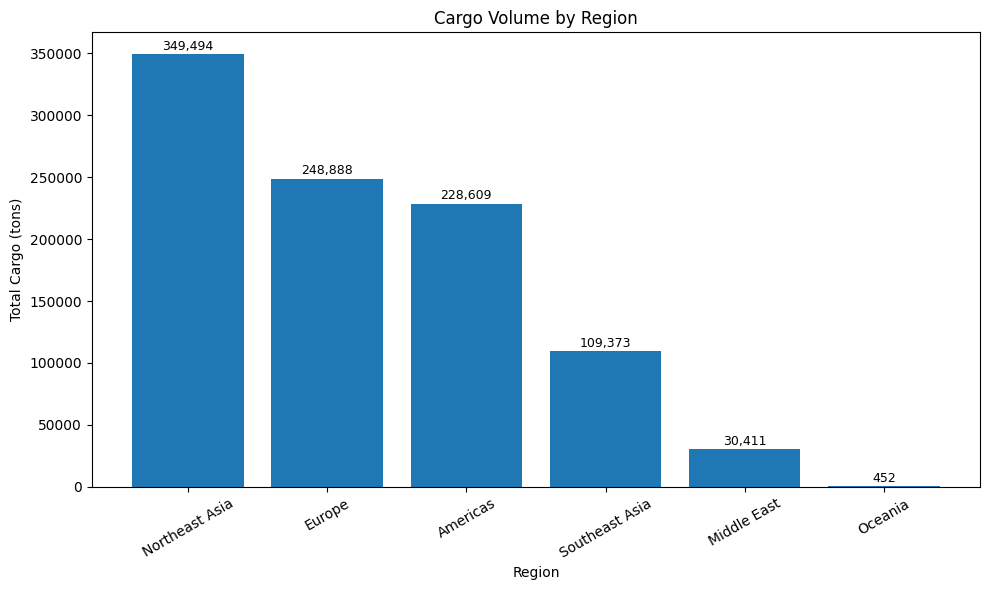

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    cargo_by_region["region_x"],
    cargo_by_region["total_cargo_tons"]
)

plt.title("Cargo Volume by Region")
plt.xlabel("Region")
plt.ylabel("Total Cargo (tons)")

plt.xticks(rotation=30)




for i, value in enumerate(cargo_by_region["total_cargo_tons"]):
    plt.text(
        i,
        value + cargo_by_region["total_cargo_tons"].max() * 0.01,
        f"{value:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Insight

- Northeast Asia handled the largest cargo volume, accounting for approximately 349,000 tons.
- Europe ranked second with around 249,000 tons, followed closely by the Americas with approximately 229,000 tons.
- Southeast Asia also showed substantial cargo activity, highlighting its role as a major logistics hub.
- The Middle East processed a relatively small volume, while Oceania recorded the lowest cargo volume in the dataset.
- These results indicate that East Asia remains the primary air cargo market connected to Incheon International Airport.

# Analysis 6

## Business Question

Which regions are net exporters and which are net importers?

In [56]:
net_by_region = (
    df.groupby("region_x", as_index=False)["net_cargo_flow"]
      .sum()
      .sort_values(
          by="net_cargo_flow",
          ascending=False
      )
)

net_by_region

,region_x,net_cargo_flow
3,Northeast Asia,33507
5,Southeast Asia,21115
2,Middle East,7924
4,Oceania,-452
0,Americas,-5568
1,Europe,-74409


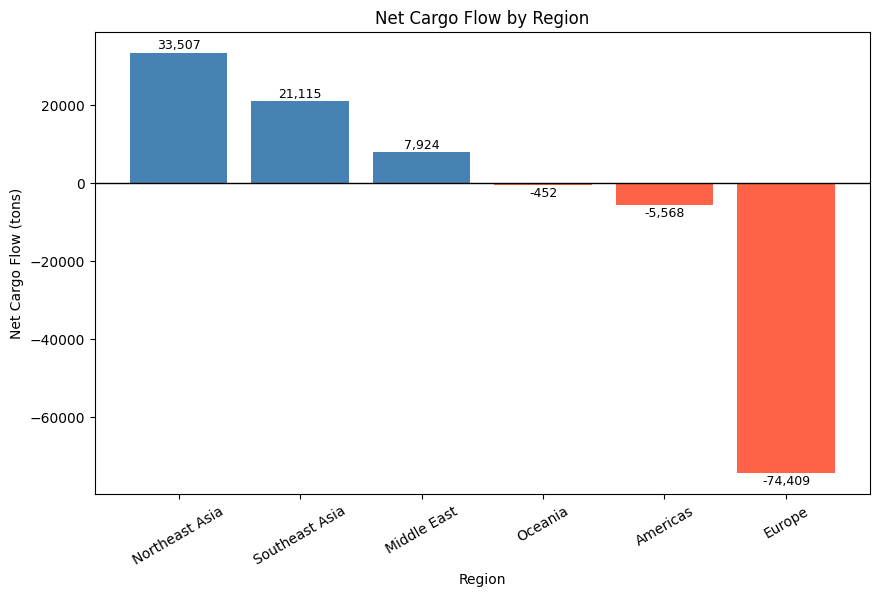

In [57]:
import matplotlib.pyplot as plt

colors = [
    "steelblue" if x >= 0 else "tomato"
    for x in net_by_region["net_cargo_flow"]
]

plt.figure(figsize=(10,6))

plt.bar(
    net_by_region["region_x"],
    net_by_region["net_cargo_flow"],
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Net Cargo Flow by Region")
plt.xlabel("Region")
plt.ylabel("Net Cargo Flow (tons)")

plt.xticks(rotation=30)

for i, value in enumerate(net_by_region["net_cargo_flow"]):
    if value >= 0:
        plt.text(
            i,
            value + 1000,
            f"{value:,}",
            ha="center",
            fontsize=9
        )
    else:
        plt.text(
            i,
            value - 3000,
            f"{value:,}",
            ha="center",
            fontsize=9
        )

## Insight

- Northeast Asia recorded the highest positive net cargo flow (+33,507 tons), indicating that exports exceeded imports in this region.
- Southeast Asia (+21,115 tons) and the Middle East (+7,924 tons) also acted as net exporters.
- Europe recorded the largest negative net cargo flow (-74,409 tons), meaning imports significantly exceeded exports.
- The Americas showed a slightly negative trade balance (-5,568 tons), while Oceania remained nearly balanced.
- These results reveal that cargo volume alone does not represent trade balance. Although Europe handled a high cargo volume, it functioned primarily as a net import region in this dataset.

# Analysis 7

## Business Question

Does route distance affect cargo volume?

In [58]:
top_export = (
    df.sort_values(
        by="departure_ratio",
        ascending=False
    )
    .head(10)
)

top_export[
    ["country", "departure_ratio", "arrival_ratio"]
]

top_export = (
    df[df["total_cargo_tons"] >= 10000]
      .sort_values(by="departure_ratio", ascending=False)
      .head(10)
)

In [59]:
top_export[
    [
        "country",
        "departure_cargo_tons",
        "arrival_cargo_tons",
        "total_cargo_tons",
        "departure_ratio"
    ]
]

,country,departure_cargo_tons,arrival_cargo_tons,total_cargo_tons,departure_ratio
27,Austria,16140,0,16140,1.000000
10,Hong Kong,48929,24111,73039,0.669902
3,Vietnam,55375,28851,84226,0.657457
20,Luxembourg,10306,6073,16379,0.629220
25,Azerbaijan,12245,7358,19602,0.624681
37,Qatar,18276,11244,29519,0.619127
31,Turkey,8662,6732,15394,0.562687
34,Japan,46301,42785,89086,0.519734
12,United States,110606,107313,217919,0.507556
35,China,93207,91039,184246,0.505883


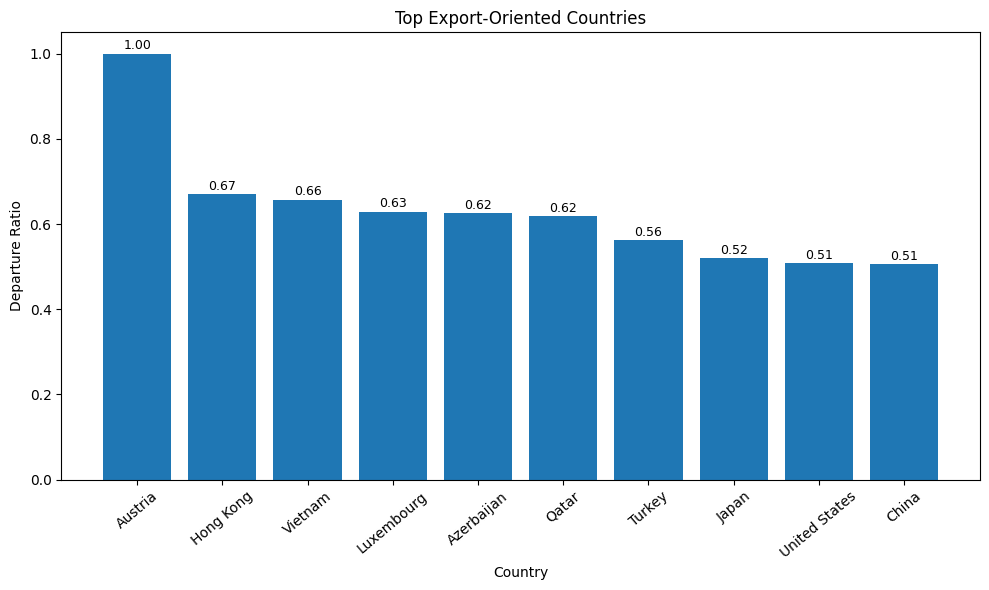

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top_export["country"],
    top_export["departure_ratio"]
)

plt.title("Top Export-Oriented Countries")
plt.xlabel("Country")
plt.ylabel("Departure Ratio")

plt.xticks(rotation=40)

for i, value in enumerate(top_export["departure_ratio"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Insight

- Austria recorded the highest departure ratio (1.00), indicating that nearly all cargo traffic was outbound.
- Hong Kong and Vietnam also showed strong export-oriented characteristics, with departure ratios above 0.65.
- Japan, China, and the United States exhibited more balanced cargo flows, with departure ratios close to 0.50.
- The departure ratio complements total cargo volume by highlighting the direction of cargo movement rather than its scale.